# Titanic EDA

This notebook performs a quick exploratory data analysis on the Titanic dataset.
It covers the basic dataset checks, followed by short univariate and bivariate analysis.

## 1. Import Libraries and Load Data

The notebook first looks for a local Titanic CSV. If none is found, it loads the dataset from a public CSV URL.

In [1]:
import io
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid')

# Try local Titanic files first so the notebook still works if you add your own dataset later.
candidate_paths = [
    Path('datasets/titanic.csv'),
    Path('../datasets/titanic.csv'),
    Path('titanic.csv'),
]

data_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

for candidate in candidate_paths:
    if candidate.exists():
        df = pd.read_csv(candidate)
        source = str(candidate)
        break
else:
    df = pd.read_csv(data_url)
    source = data_url

print(f'Dataset source: {source}')
print(f'Dataset shape: {df.shape}')

Dataset source: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)


## 2. Understanding the Data

These checks match the operations listed in your note file.

In [2]:
# 1) Size of the data
print('Rows and columns:', df.shape)

# 2) Preview the dataset
display(df.head())

# 3) Data types and non-null counts
buffer = io.StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

# 4) Missing values in each column
print('Missing values by column:')
print(df.isnull().sum())

# 5) Statistical summary
display(df.describe(include='all').T)

# 6) Duplicate rows
print('Duplicate rows:', df.duplicated().sum())

# 7) Correlation between numeric columns
numeric_df = df.select_dtypes(include='number')
display(numeric_df.corr(numeric_only=True))

Rows and columns: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values by column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtyp

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


Duplicate rows: 0


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## 3. Univariate Analysis

Univariate analysis studies one variable at a time. Here we inspect survival, passenger class, age, and fare.

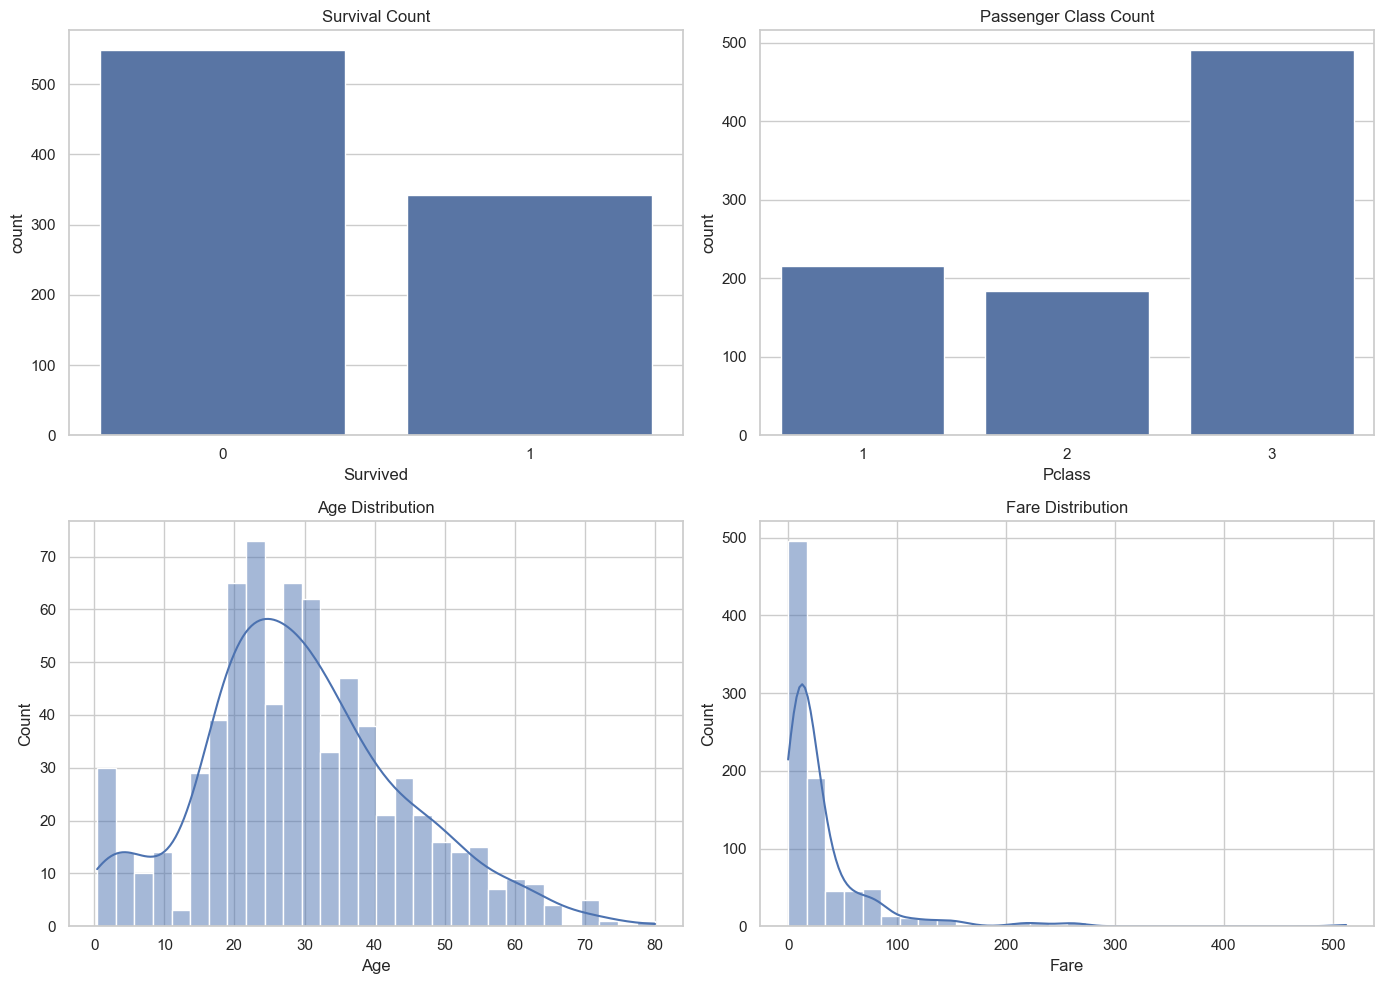

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of survival values
sns.countplot(data=df, x='Survived', ax=axes[0, 0])
axes[0, 0].set_title('Survival Count')

# Distribution of passenger class
sns.countplot(data=df, x='Pclass', ax=axes[0, 1])
axes[0, 1].set_title('Passenger Class Count')

# Age distribution
sns.histplot(df['Age'].dropna(), bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Age Distribution')

# Fare distribution
sns.histplot(df['Fare'], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Fare Distribution')

plt.tight_layout()

## 4. Bivariate Analysis

Bivariate analysis studies the relationship between two variables. Below we compare survival with sex and class, and examine the correlation heatmap.

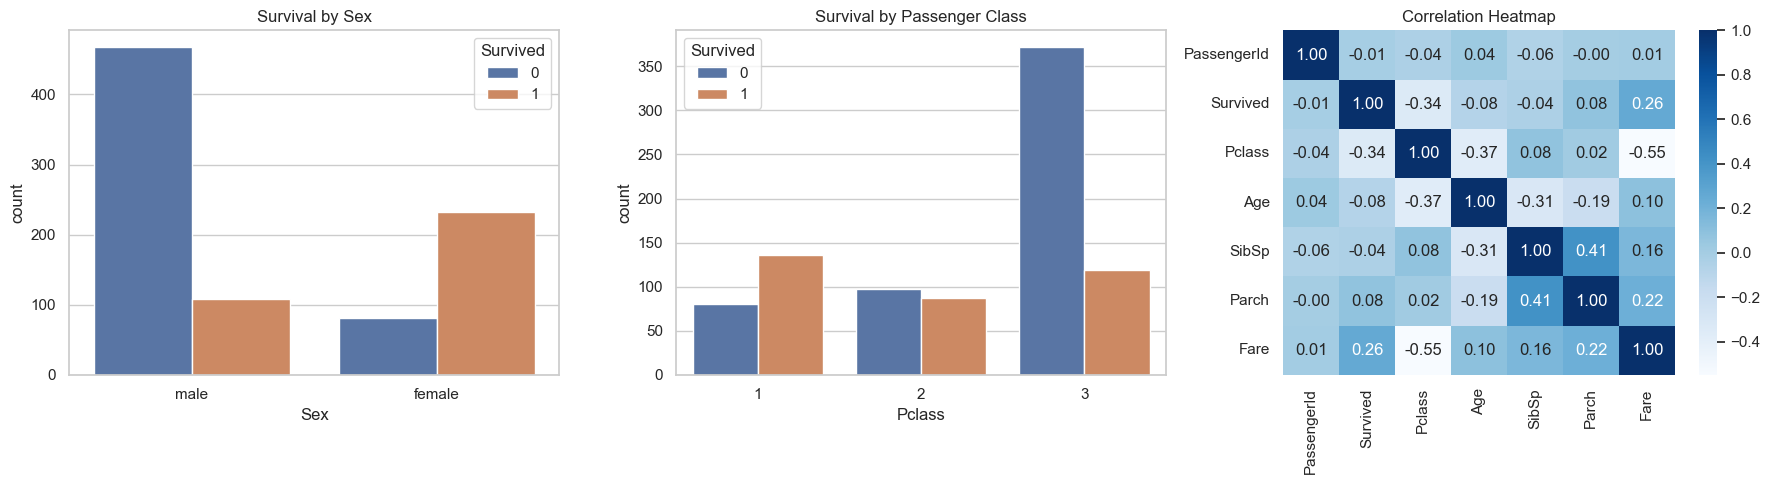

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Survival by sex
sns.countplot(data=df, x='Sex', hue='Survived', ax=axes[0])
axes[0].set_title('Survival by Sex')

# Survival by passenger class
sns.countplot(data=df, x='Pclass', hue='Survived', ax=axes[1])
axes[1].set_title('Survival by Passenger Class')

# Correlation heatmap for numeric columns
sns.heatmap(numeric_df.corr(numeric_only=True), annot=True, cmap='Blues', fmt='.2f', ax=axes[2])
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()